## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

%matplotlib inline

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

## 2. Load Processed Data

In [2]:
df = pd.read_csv("/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/data/processed/news.csv")

In [3]:
df.head()

,title,text,subject,date,label,article_content,clean_text
0,It’s Really Happening: Trump Adviser Lays Out Plan For National Muslim Registry,"Well, that didn t take long. In the short time since Americans kinda-sorta elected Donald Trump to be Pussygrabber-in-Chief, Trump has appointed a bona fide white nationalist to a high-level posit...",News,2016-11-16,1,"It’s Really Happening: Trump Adviser Lays Out Plan For National Muslim Registry Well, that didn t take long. In the short time since Americans kinda-sorta elected Donald Trump to be Pussygrabber-...",it’s really happening trump adviser lay plan national muslim registry well take long short time since american kindasorta elected donald trump pussygrabberinchief trump appointed bona fide white n...
1,Republican attempt to deflect Trump-Russia probes could backfire: sources,(Reuters) - Republican lawmaker Devin Nunes’ investigation into whether Obama administration officials used classified intelligence reports to discredit Donald Trump’s 2016 campaign team could bac...,politicsNews,2017-09-11,0,Republican attempt to deflect Trump-Russia probes could backfire: sources (Reuters) - Republican lawmaker Devin Nunes’ investigation into whether Obama administration officials used classified int...,republican attempt deflect trumprussia probe could backfire source reuters republican lawmaker devin nunes’ investigation whether obama administration official used classified intelligence report ...
2,Trump says churches should get FEMA funds for hurricane relief,WASHINGTON (Reuters) - President Donald Trump said on Friday that churches in Texas should be able to receive money from the Federal Emergency Management Agency for helping victims of Hurricane Ha...,politicsNews,2017-09-09,0,Trump says churches should get FEMA funds for hurricane relief WASHINGTON (Reuters) - President Donald Trump said on Friday that churches in Texas should be able to receive money from the Federal ...,trump say church get fema fund hurricane relief washington reuters president donald trump said friday church texas able receive money federal emergency management agency helping victim hurricane h...
3,Trump Loves To Say The New York Times Is ‘Failing’ – So They Just Effortlessly Embarrassed Him With Simple Numbers,"Print journalism and longstanding papers have been struggling since the advent of the internet and increased competition faced by blogs and op-ed sites. That, combined with poor understanding of m...",News,2017-08-07,1,Trump Loves To Say The New York Times Is ‘Failing’ – So They Just Effortlessly Embarrassed Him With Simple Numbers Print journalism and longstanding papers have been struggling since the advent o...,trump love say new york time ‘failing’ – effortlessly embarrassed simple number print journalism longstanding paper struggling since advent internet increased competition faced blog oped site comb...
4,House Speaker Ryan briefed Trump on healthcare bill voting: White House,"WASHINGTON (Reuters) - President Donald Trump was being briefed on Friday by House Speaker Paul Ryan about the status of voting on the Republican bill to replace Obamacare, the White House said am...",politicsNews,2017-03-24,0,House Speaker Ryan briefed Trump on healthcare bill voting: White House WASHINGTON (Reuters) - President Donald Trump was being briefed on Friday by House Speaker Paul Ryan about the status of vot...,house speaker ryan briefed trump healthcare bill voting white house washington reuters president donald trump briefed friday house speaker paul ryan status voting republican bill replace obamacare...


In [4]:
df.shape

(44689, 7)

## 3. data overview

In [5]:
# check the columns
df.columns

Index(['title', 'text', 'subject', 'date', 'label', 'article_content',
       'clean_text'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44689 entries, 0 to 44688
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   title            44689 non-null  str  
 1   text             44689 non-null  str  
 2   subject          44689 non-null  str  
 3   date             44679 non-null  str  
 4   label            44689 non-null  int64
 5   article_content  44689 non-null  str  
 6   clean_text       44680 non-null  str  
dtypes: int64(1), str(6)
memory usage: 297.0 MB


In [7]:
# descriptive statistic
df.describe(include="all")

,title,text,subject,date,label,article_content,clean_text
count,44689,44689,44689,44679,44689.000000,44689,44680
unique,38729,38646,8,1010,NaN,39105,39094
top,Factbox: Trump fills top jobs for his administration,,politicsNews,2017-12-06,NaN,ELEMENTARY SCHOOL PLANS ‘BLACKS ONLY’ FIELD TRIP TO COLLEGE FOR THIRD GRADERS Because there wouldn t be any outrage over a white kids only field trip to a local college would there?Parents criti...,medium ignores time bill clinton fired fbi director day vince foster found dead year history one fbi director fired tuesday president trump fired james b comey july president bill clinton fired wi...
freq,14,627,11220,183,NaN,4,4
mean,NaN,NaN,NaN,NaN,0.525364,NaN,NaN
std,NaN,NaN,NaN,NaN,0.499362,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


## 4. Data Quality Check

In [8]:
df.isnull().sum()

title               0
text                0
subject             0
date               10
label               0
article_content     0
clean_text          9
dtype: int64

In [9]:
# check duplicate
df.duplicated().sum()

np.int64(0)

In [10]:
df.groupby("label").size()

label
0    21211
1    23478
dtype: int64

## 5. Target/Class Distribution

In [11]:
df.groupby("label").size()
df["label"].value_counts(normalize=True) * 100

label
1    52.536418
0    47.463582
Name: proportion, dtype: float64

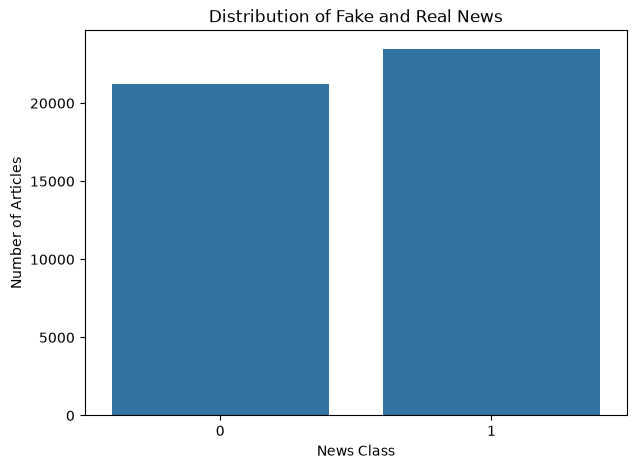

In [12]:
# plot the distribution
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="label")

plt.title("Distribution of Fake and Real News")
plt.xlabel("News Class")
plt.ylabel("Number of Articles")

plt.show()

## 6. Subject Analysis

In [13]:
df["subject"].value_counts()

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

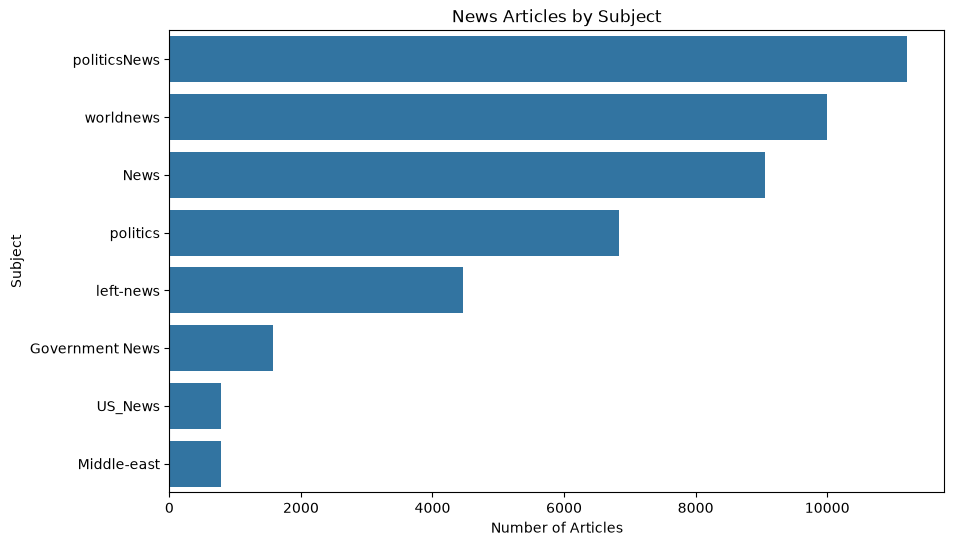

In [14]:
# plot the distribution of subject
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="subject",
    order=df["subject"].value_counts().index
)

plt.title("News Articles by Subject")
plt.xlabel("Number of Articles")
plt.ylabel("Subject")

plt.show()

In [15]:
pd.crosstab(df["subject"], df["label"])

label,0,1
subject,,
Government News,0,1570
Middle-east,0,778
News,0,9050
US_News,0,783
left-news,0,4459
politics,0,6838
politicsNews,11220,0
worldnews,9991,0


In [16]:
# investigate subject versus class
pd.crosstab(
    df["subject"],
    df["label"],
    normalize="index"
).round(3)

label,0,1
subject,,
Government News,0.0,1.0
Middle-east,0.0,1.0
News,0.0,1.0
US_News,0.0,1.0
left-news,0.0,1.0
politics,0.0,1.0
politicsNews,1.0,0.0
worldnews,1.0,0.0


## 7. Date/Time Analysis

In [18]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [19]:
df["date"].isna().sum()

np.int64(10)

In [20]:
df["date"].min(), df["date"].max()

(Timestamp('2015-03-31 00:00:00'), Timestamp('2018-02-19 00:00:00'))

In [21]:
# create month / year
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

In [ ]:
# check article per yr
df["year"].value_counts().sort_index()

year
2015.0     2479
2016.0    16470
2017.0    25904
2018.0       35
Name: count, dtype: int64

In [22]:
pd.crosstab(
    df["year"],
    df["label"],
    normalize="index"
).round(3)

label,0,1
year,,
2015.0,0.000,1.000
2016.0,0.286,0.714
2017.0,0.642,0.358
2018.0,0.000,1.000


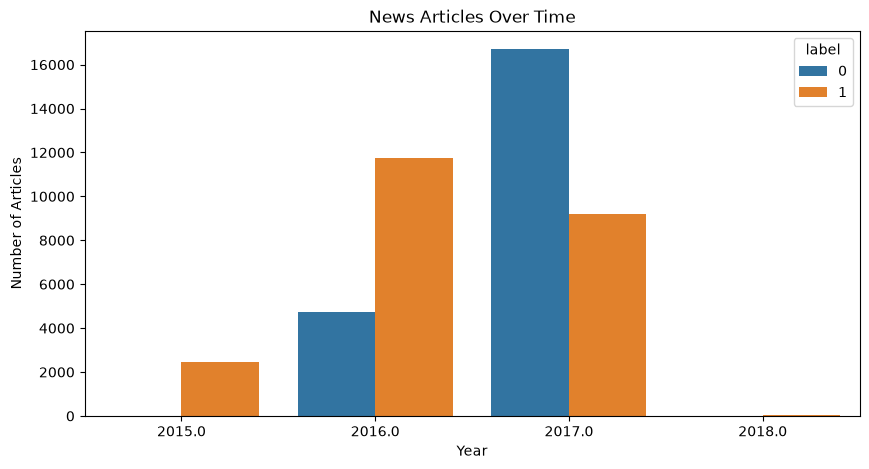

In [ ]:
# make the plot
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="year",
    hue="label"
)

plt.title("News Articles Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Articles")

plt.show()

## 8. Text Analysis

In [23]:
# text length
df["text_length"] = df["text"].fillna("").str.len()

In [24]:
# word count
df["word_count"] = (
    df["text"]
    .fillna("")
    .str.split()
    .str.len()
)

In [25]:
# inpect
df[["text_length", "word_count"]].describe()

,text_length,word_count
count,44689.000000,44689.000000
mean,2467.098682,404.966502
std,2173.612347,351.573770
min,1.000000,0.000000
25%,1232.000000,203.000000
50%,2185.000000,362.000000
75%,3101.000000,512.000000
max,51794.000000,8135.000000


## 9. Fake vs Real Text Comparison

In [ ]:
df.groupby("label")[["text_length", "word_count"]].describe()

text_length                                                         \
            count         mean          std  min     25%     50%     75%   
label                                                                      
0         21417.0  2383.278517  1684.835730  1.0   914.0  2222.0  3237.0   
1         23481.0  2547.396235  2532.884399  1.0  1433.0  2166.0  3032.0   

               word_count                                                    \
           max      count        mean         std  min    25%    50%    75%   
label                                                                         
0      29781.0    21417.0  385.640099  274.006204  0.0  148.0  359.0  525.0   
1      51794.0    23481.0  423.197905  408.388890  0.0  240.0  363.0  506.0   

               
          max  
label          
0      5172.0  
1      8135.0

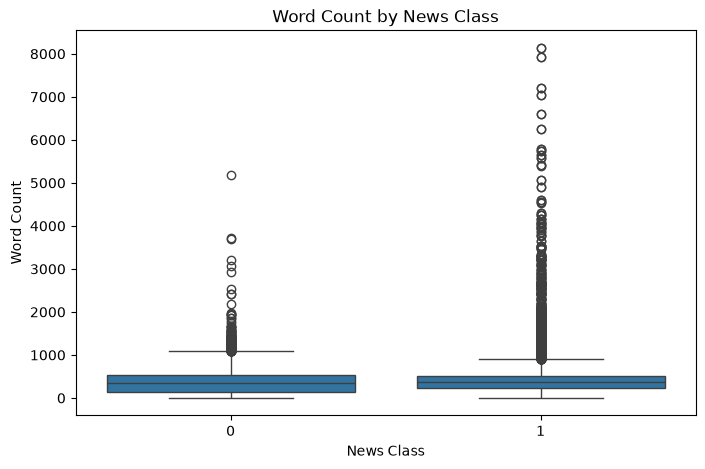

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="word_count"
)

plt.title("Word Count by News Class")
plt.xlabel("News Class")
plt.ylabel("Word Count")

plt.show()

In [26]:
# title_length column
df["title_length"] = df["title"].fillna("").str.len()

In [27]:
df.groupby("label")["title_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,21211.0,64.658291,9.162659,26.0,59.0,64.0,70.0,133.0
1,23478.0,94.194054,27.183524,8.0,77.0,90.0,105.0,286.0


## 10. Most common word

In [ ]:
from collections import Counter
import re

text = " ".join(df["text"].fillna("").astype(str))

words = re.findall(r"\b[a-zA-Z]+\b", text.lower())

word_counts = Counter(words)

word_counts.most_common(20)

[('the', 1026019),
 ('to', 536553),
 ('of', 441915),
 ('a', 413363),
 ('and', 409052),
 ('in', 352815),
 ('s', 282576),
 ('that', 239899),
 ('on', 192185),
 ('for', 173375),
 ('is', 166728),
 ('trump', 134000),
 ('he', 133367),
 ('it', 132970),
 ('said', 132825),
 ('with', 117923),
 ('was', 115803),
 ('as', 105098),
 ('his', 96369),
 ('by', 95852)]

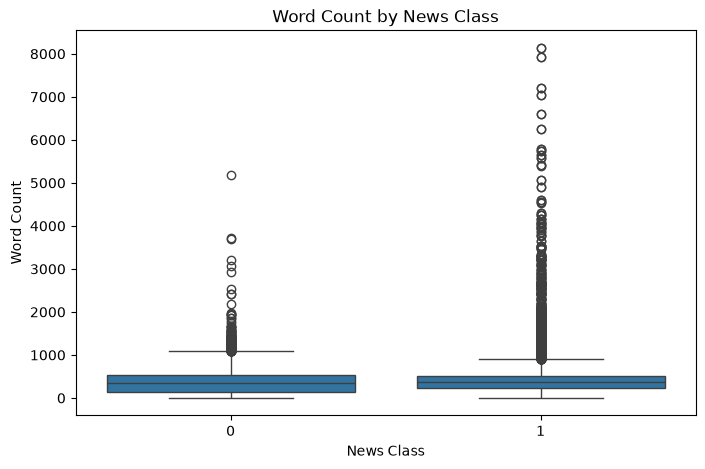

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="word_count"
)

plt.title("Word Count by News Class")
plt.xlabel("News Class")
plt.ylabel("Word Count")

plt.show()

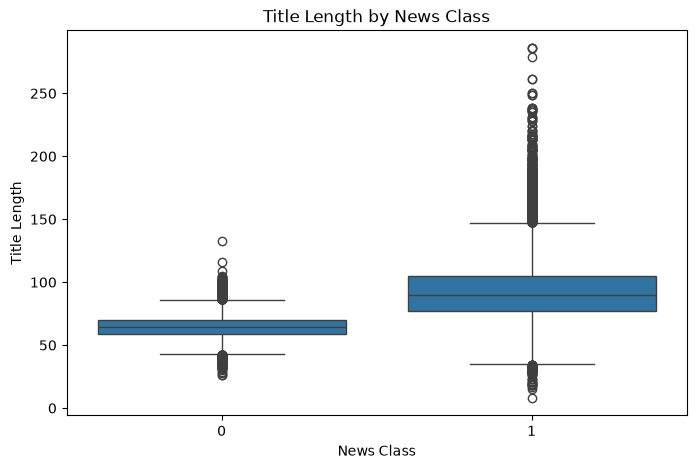

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="title_length"
)

plt.title("Title Length by News Class")
plt.xlabel("News Class")
plt.ylabel("Title Length")

plt.show()

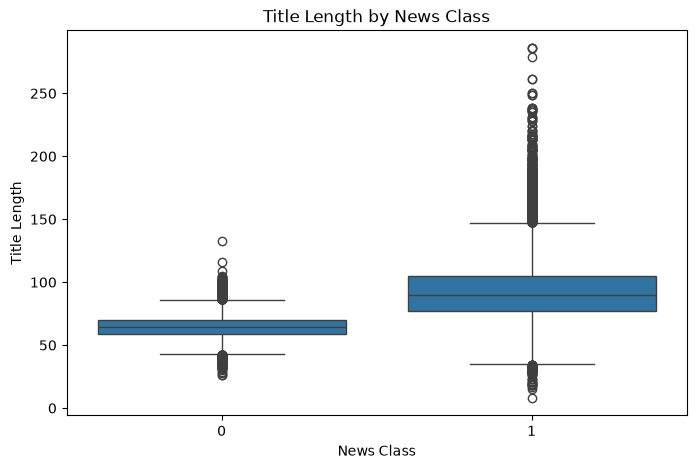

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="title_length"
)

plt.title("Title Length by News Class")
plt.xlabel("News Class")
plt.ylabel("Title Length")

plt.show()

# 11. Key Findings

## Dataset Overview

- Total articles: 44,898
- Features: title, text, subject, date, label
- Missing dates: 10
- Duplicate records: 209
- Class 0: 21,417 (47.70%)
- Class 1: 23,481 (52.29%)

## Class Distribution

The dataset is relatively balanced, with class 1 representing 52.29%
and class 0 representing 47.70% of the observations.

## Subject Analysis

Subject is perfectly associated with the target class in this dataset.
Some subjects occur exclusively within class 0 while others occur
exclusively within class 1.

Therefore, subject will not be used as a predictive feature because
it could introduce severe dataset/source bias.

## Temporal Analysis

The distribution of labels varies substantially across publication
years. Some years contain articles exclusively from one class.

Therefore, date-derived variables will not be used as predictive
features in the initial content-based model.

## Text Analysis

Article length varies considerably across the dataset. The mean article
contains approximately 405 words, while the median is approximately
362 words.

The distribution is right-skewed because a small number of articles
are substantially longer.

## Title Analysis

Average title length differs between the two classes. Class 1 articles
have longer titles on average than class 0 articles in this dataset.

This is an observed dataset characteristic and does not imply that
longer titles inherently indicate fake news.

## Modeling Decision

The initial classifier will use:

- title
- text

The following variables will be excluded from the initial predictive
model:

- subject
- date
- year
- month

This is intended to reduce dataset/source bias and encourage the model
to learn patterns from the actual news content.

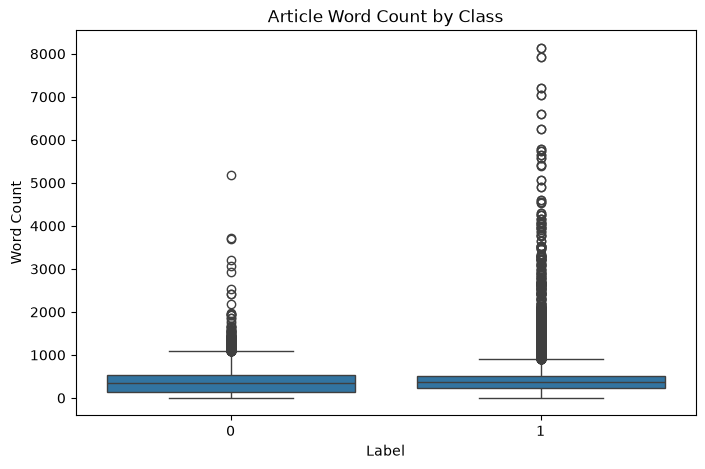

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="word_count"
)

plt.title("Article Word Count by Class")
plt.xlabel("Label")
plt.ylabel("Word Count")

plt.show()

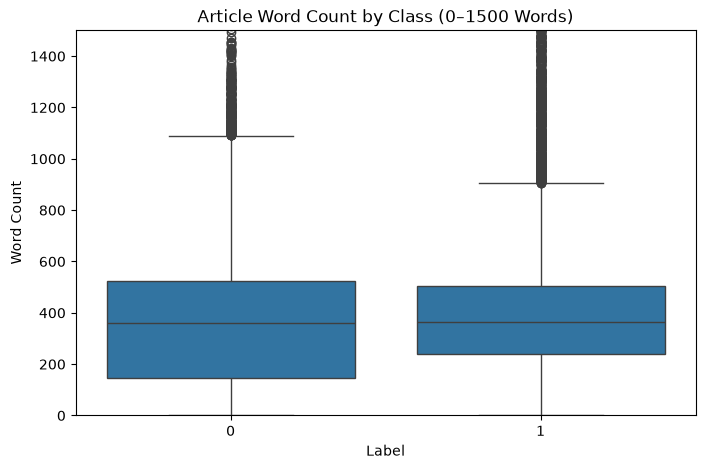

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="word_count"
)

plt.ylim(0, 1500)

plt.title("Article Word Count by Class (0–1500 Words)")
plt.xlabel("Label")
plt.ylabel("Word Count")

plt.show()

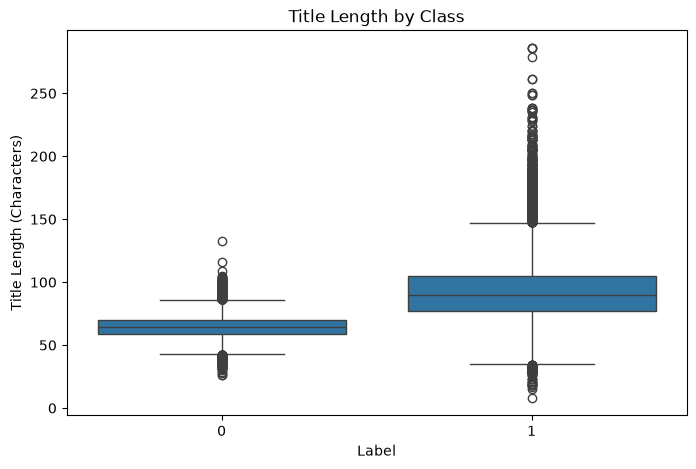

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="title_length"
)

plt.title("Title Length by Class")
plt.xlabel("Label")
plt.ylabel("Title Length (Characters)")

plt.show()

In [ ]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to C:\Users\EXOTISCH
[nltk_data]     TECH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [31]:
from nltk.corpus import stopwords
import re
from collections import Counter

stop_words = set(stopwords.words("english"))

In [32]:
def get_common_words(text_series, n=20):
    text = " ".join(text_series.fillna("").astype(str)).lower()
    
    words = re.findall(r"\b[a-zA-Z]+\b", text)
    
    words = [
        word for word in words
        if word not in stop_words
    ]
    
    return Counter(words).most_common(n)

In [33]:
get_common_words(df["text"], 20)

[('trump', 133398),
 ('said', 131629),
 ('president', 55593),
 ('would', 54810),
 ('u', 53749),
 ('people', 41659),
 ('one', 37777),
 ('state', 34271),
 ('also', 31157),
 ('new', 31152),
 ('reuters', 29130),
 ('clinton', 28633),
 ('obama', 28128),
 ('donald', 28053),
 ('government', 27753),
 ('house', 27605),
 ('states', 26612),
 ('republican', 25474),
 ('year', 24820),
 ('could', 23784)]

In [34]:
class_0_words = get_common_words(
    df.loc[df["label"] == 0, "text"],
    20
)

class_0_words

[('said', 97867),
 ('trump', 54098),
 ('u', 44029),
 ('would', 31249),
 ('reuters', 28681),
 ('president', 27879),
 ('state', 20808),
 ('government', 18552),
 ('new', 16758),
 ('house', 16492),
 ('states', 16422),
 ('republican', 16149),
 ('also', 15754),
 ('united', 15368),
 ('people', 15089),
 ('year', 14599),
 ('told', 14072),
 ('could', 13538),
 ('one', 13250),
 ('washington', 12889)]

In [35]:
class_1_words = get_common_words(
    df.loc[df["label"] == 1, "text"],
    20
)

class_1_words

[('trump', 79300),
 ('said', 33762),
 ('president', 27714),
 ('people', 26570),
 ('one', 24527),
 ('would', 23561),
 ('clinton', 19168),
 ('obama', 18797),
 ('like', 18096),
 ('donald', 17671),
 ('also', 15403),
 ('us', 14678),
 ('news', 14620),
 ('new', 14394),
 ('hillary', 14117),
 ('even', 14011),
 ('time', 13843),
 ('state', 13463),
 ('white', 13185),
 ('via', 12774)]

# Conclusion

The exploratory analysis provided several important findings.

1. The dataset contains 44,898 news articles and is relatively balanced
   between the two target classes.

2. There are 209 duplicate observations and 10 missing date values.

3. The `subject` variable has a perfect relationship with the target
   class in this dataset. Therefore, it will not be used as a predictive
   feature because it could introduce severe source-related bias.

4. The distribution of the target class also varies substantially
   across publication years. Date-derived variables will therefore
   not be included in the initial content-based classifier.

5. Article and title lengths differ between the two classes.

6. The text contains distinguishable vocabulary patterns between the
   classes, motivating the use of NLP-based feature extraction.

## Modeling Strategy

The initial classifier will focus on the actual textual content:

- title
- article text

The following variables will be excluded:

- subject
- date
- year
- month

The next stage will transform the textual information into numerical
features suitable for machine learning.

In [36]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label', 'article_content',
       'clean_text', 'year', 'month', 'text_length', 'word_count',
       'title_length'],
      dtype='str')